<a href="https://colab.research.google.com/github/araujoluigif/Cp1-machine-learning/blob/main/Case_iFood_Parte_2_ML_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case iFood — Parte 2: Machine Learning & Modelling

Objetivo: melhorar a **Decision Tree** do notebook de referência com Feature Engineering e tuning, usando o conjunto de teste somente uma vez, na avaliação final.

Controles contra data leakage:

- HoldOut estratificado antes de qualquer ajuste orientado pela variável `Response`;
- EDA supervisionada feita somente no treino;
- imputação, One-Hot Encoding, Feature Engineering e tuning dentro do fluxo de treino;
- validação cruzada estratificada para escolher hiperparâmetros;
- teste preservado até a comparação final.

Integrantes:

-Luigi Francisco Rm: 571204

-Felipe Olmos Rm: 570946

-Diogo Romano Rm: 570732

-Breno Filipe Hernandes Rm: 571824

-Matheus Rebelo Rm: 570260

-Luiz Guilherme Rm: 573486


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.30

In [2]:
df = pd.read_csv("data.csv")

print(f"Dimensão: {df.shape[0]} linhas × {df.shape[1]} colunas")
display(df.head())

Dimensão: 2240 linhas × 29 colunas


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. Diagnóstico objetivo e HoldOut estratificado

In [3]:
# Diagnóstico objetivo dos dados

print(f"Duplicatas: {df.duplicated().sum()}")
print(f"Taxa de resposta positiva: {df['Response'].mean():.2%}")
print(f"Anos de nascimento fora de 1920–2014: {(~df['Year_Birth'].between(1920, 2014)).sum()}")
print(f"Valores nulos em Income: {df['Income'].isna().sum()}")

# Distribuição da variável alvo
display(
    df["Response"]
    .value_counts()
    .rename("quantidade")
    .to_frame()
)

Duplicatas: 0
Taxa de resposta positiva: 14.91%
Anos de nascimento fora de 1920–2014: 3
Valores nulos em Income: 24


,quantidade
Response,
0,1906
1,334


In [4]:
X = df.drop(columns="Response")
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Amostras": [len(X_train), len(X_test)],
    "Response = 1": [
        f"{y_train.mean():.2%}",
        f"{y_test.mean():.2%}"
    ]
}, index=["Treino", "Teste"])

display(split_summary)

,Amostras,Response = 1
Treino,1568,14.92%
Teste,672,14.88%


O teste fica separado a partir deste ponto. A diferença de proporção da classe positiva é mínima porque o split usa `stratify=y`. Valores ausentes e categorias ainda não foram ajustados; isso será feito dentro dos pipelines, aprendendo somente com o treino.

### EDA supervisionada somente no treino

,Recency,Income,Total_Spend
Response,,,
0,53.0,49991.0,315.0
1,28.5,64140.0,1063.0


,mean,count
Previous_Campaigns_Accepted,,
0,8.16%,1237
1,30.51%,236
2,54.24%,59
3,78.57%,28
4,87.50%,8


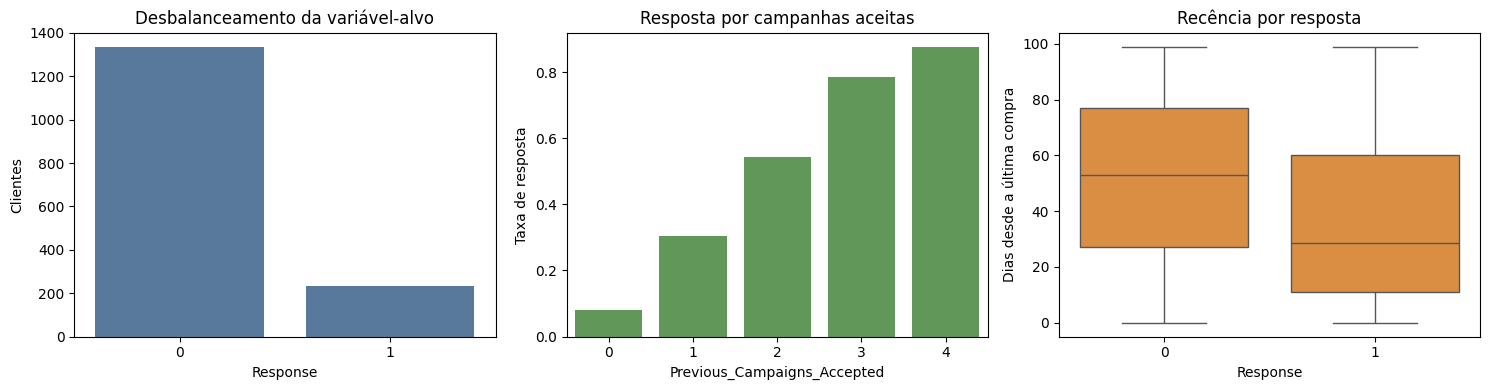

In [5]:
eda_train = X_train.copy()
eda_train["Response"] = y_train

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]

eda_train["Total_Spend"] = eda_train[spend_cols].sum(axis=1)
eda_train["Previous_Campaigns_Accepted"] = eda_train[campaign_cols].sum(axis=1)

profile = eda_train.groupby("Response")[["Recency", "Income", "Total_Spend"]].median()
campaign_response = eda_train.groupby("Previous_Campaigns_Accepted")["Response"].agg(["mean", "count"])

display(profile)
campaign_response_display = campaign_response.copy()
campaign_response_display["mean"] = campaign_response_display["mean"].map("{:.2%}".format)
display(campaign_response_display)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=eda_train, x="Response", ax=axes[0], color="#4C78A8")
axes[0].set_title("Desbalanceamento da variável-alvo")
axes[0].set_ylabel("Clientes")

sns.barplot(
    data=campaign_response.reset_index(),
    x="Previous_Campaigns_Accepted", y="mean", ax=axes[1], color="#59A14F"
)
axes[1].set_title("Resposta por campanhas aceitas")
axes[1].set_ylabel("Taxa de resposta")

sns.boxplot(data=eda_train, x="Response", y="Recency", ax=axes[2], color="#F28E2B")
axes[2].set_title("Recência por resposta")
axes[2].set_ylabel("Dias desde a última compra")

plt.tight_layout()
plt.show()

### Conclusões da EDA e features propostas

- A classe positiva é minoritária (~15%), indicando desbalanceamento da variável-alvo.
- Clientes que aceitaram campanhas anteriores apresentam maior taxa de resposta..
- Anos de nascimento incoerentes serão convertidos em ausentes e imputados dentro do pipeline.
- Aceites anteriores e recência mostram sinal de propensão. Por isso, criamos `Previous_Campaigns_Accepted` e mantemos `Recency`.
- Somatórios (`Total_Spend`, `Total_Purchases`) representam intensidade de consumo.
- Razões (`Average_Ticket`, participação por canal e por promoções) descrevem o estilo de compra, reduzindo dependência do volume bruto.
- `Age_At_Enrollment`, tempo como cliente, filhos no lar, renda por dependente e gasto por mês de relacionamento representam ciclo de vida e contexto do domicílio.

Nenhuma nova feature usa `Response`.

## 3. Feature Engineering e preparação sem leakage

In [6]:
class ReferenceFeatureEngineer(BaseEstimator, TransformerMixin):
    """Features usadas no modelo de referência."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        date = pd.to_datetime(X["Dt_Customer"], errors="coerce")

        X["Age"] = 2017 - X["Year_Birth"]
        X["Time_Customer"] = (pd.Timestamp("2017-01-01") - date).dt.days / 365

        return X.drop(
            columns=["ID", "Z_CostContact", "Z_Revenue", "Dt_Customer", "Year_Birth"],
            errors="ignore"
        )


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Cria novas features sem utilizar a variável-alvo."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        date = pd.to_datetime(X["Dt_Customer"], errors="coerce")

        birth = X["Year_Birth"].where(X["Year_Birth"].between(1920, 2014))
        X["Age_At_Enrollment"] = date.dt.year - birth
        X["Customer_Tenure_Months"] = (
            (2014 - date.dt.year) * 12 + (12 - date.dt.month)
        ).clip(lower=0)

        spend = [
            "MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"
        ]
        purchases = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
        campaigns = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                     "AcceptedCmp4", "AcceptedCmp5"]

        X["Total_Spend"] = X[spend].sum(axis=1)
        X["Total_Purchases"] = X[purchases].sum(axis=1)
        X["Children_Home"] = X["Kidhome"] + X["Teenhome"]
        X["Previous_Campaigns_Accepted"] = X[campaigns].sum(axis=1)

        X["Average_Ticket"] = X["Total_Spend"] / X["Total_Purchases"].replace(0, np.nan)
        X["Web_Purchase_Share"] = X["NumWebPurchases"] / X["Total_Purchases"].replace(0, np.nan)
        X["Catalog_Purchase_Share"] = X["NumCatalogPurchases"] / X["Total_Purchases"].replace(0, np.nan)
        X["Deal_Purchase_Share"] = X["NumDealsPurchases"] / X["Total_Purchases"].replace(0, np.nan)
        X["Income_Per_Dependent"] = X["Income"] / (1 + X["Children_Home"])
        X["Spend_Per_Tenure_Month"] = X["Total_Spend"] / (1 + X["Customer_Tenure_Months"])
        X["Is_Parent"] = (X["Children_Home"] > 0).astype(int)

        return X.drop(
            columns=["ID", "Z_CostContact", "Z_Revenue", "Dt_Customer", "Year_Birth"],
            errors="ignore"
        )

In [7]:
# Preparação dos dados

feature_preview = FeatureEngineer().fit_transform(X_train.head())

categorical_cols = ["Education", "Marital_Status"]
numeric_cols = [
    col for col in feature_preview.columns
    if col not in categorical_cols
]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", Pipeline(steps=[]))
    ]), numeric_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

model_pipeline = Pipeline([
    ("features", FeatureEngineer()),
    ("prep", preprocessor),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

print(f"Features numéricas: {len(numeric_cols)}")
print(f"Features categóricas: {categorical_cols}")

Features numéricas: 34
Features categóricas: ['Education', 'Marital_Status']


## 4. Modelo de referência

A referência segue a conclusão do notebook fornecido: `SMOTE` e árvore com `max_depth=6`. Para tornar a comparação válida, o One-Hot Encoding e o SMOTE são ajustados somente no treino. A referência usa apenas `Age` e `Time_Customer`, como na aula, sem as novas features.

In [8]:
# Modelo de referência

reference_engineer = ReferenceFeatureEngineer()

X_train_ref = reference_engineer.fit_transform(X_train)
X_test_ref = reference_engineer.transform(X_test)

categorical = ["Education", "Marital_Status"]
numeric = [col for col in X_train_ref.columns if col not in categorical]

reference_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

X_train_ref = reference_preprocessor.fit_transform(X_train_ref)

X_train_smote, y_train_smote = SMOTE(
    random_state=RANDOM_STATE
).fit_resample(X_train_ref, y_train)

reference_tree = DecisionTreeClassifier(
    max_depth=6,
    random_state=RANDOM_STATE
)

reference_tree.fit(X_train_smote, y_train_smote)

print("Modelo de referência treinado somente com os dados de treino.")

Modelo de referência treinado somente com os dados de treino.


## 5. Tuning da Decision Tree somente no treino

In [9]:
# Preparação dos dados

feature_preview = FeatureEngineer().fit_transform(X_train.head())

categorical_cols = ["Education", "Marital_Status"]
numeric_cols = [
    col for col in feature_preview.columns
    if col not in categorical_cols
]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

model_pipeline = Pipeline([
    ("features", FeatureEngineer()),
    ("prep", preprocessor),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

print(f"Features numéricas: {len(numeric_cols)}")
print(f"Features categóricas: {categorical_cols}")

Features numéricas: 34
Features categóricas: ['Education', 'Marital_Status']


A busca otimiza `ROC AUC`, pois essa métrica avalia a ordenação das probabilidades em vários limiares e é o objetivo principal da atividade. O limiar de classificação permanece em 0,50; ele não é escolhido olhando o teste.

In [10]:
# Tuning da Decision Tree somente no treino

param_distributions = {
    "tree__criterion": ["gini", "entropy", "log_loss"],
    "tree__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "tree__min_samples_split": randint(2, 61),
    "tree__min_samples_leaf": randint(1, 41),
    "tree__max_features": [None, "sqrt", "log2", 0.6, 0.8],
    "tree__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ],
    "tree__ccp_alpha": uniform(0, 0.02)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)

print(f"Melhor ROC AUC médio na validação cruzada: {search.best_score_:.4f}")

display(
    pd.Series(search.best_params_, name="valor")
    .rename_axis("parâmetro")
    .to_frame()
)

Melhor ROC AUC médio na validação cruzada: 0.8204


,valor
parâmetro,
tree__ccp_alpha,0.012119
tree__class_weight,balanced
tree__criterion,log_loss
tree__max_depth,4
tree__max_features,None
tree__min_samples_leaf,28
tree__min_samples_split,8


## 6. Avaliação final no teste preservado

In [11]:
def metric_row(model_name, y_true, y_pred, y_score):
    return {
        "Modelo": model_name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
    }

# Avaliação final no teste preservado

# Prepara o teste para o modelo de referência
reference_test = reference_engineer.transform(X_test)
X_test_ref = reference_preprocessor.transform(reference_test)

reference_score = reference_tree.predict_proba(X_test_ref)[:, 1]
reference_pred = reference_tree.predict(X_test_ref)

# Modelo melhorado
final_model = search.best_estimator_
final_score = final_model.predict_proba(X_test)[:, 1]
final_pred = final_model.predict(X_test)

# Comparação
comparison = pd.DataFrame([
    metric_row(
        "Referência: SMOTE + depth=6",
        y_test, reference_pred, reference_score
    ),
    metric_row(
        "Decision Tree melhorada",
        y_test, final_pred, final_score
    )
]).set_index("Modelo")

display(comparison.round(3))

auc_gain = (
    comparison.loc["Decision Tree melhorada", "ROC AUC"]
    - comparison.loc["Referência: SMOTE + depth=6", "ROC AUC"]
)

print(f"Ganho absoluto de ROC AUC: {auc_gain:.3f}")

,Precision,Recall,F1-score,ROC AUC
Modelo,,,,
Referência: SMOTE + depth=6,0.432,0.38,0.404,0.722
Decision Tree melhorada,0.294,0.90,0.443,0.826


Ganho absoluto de ROC AUC: 0.104


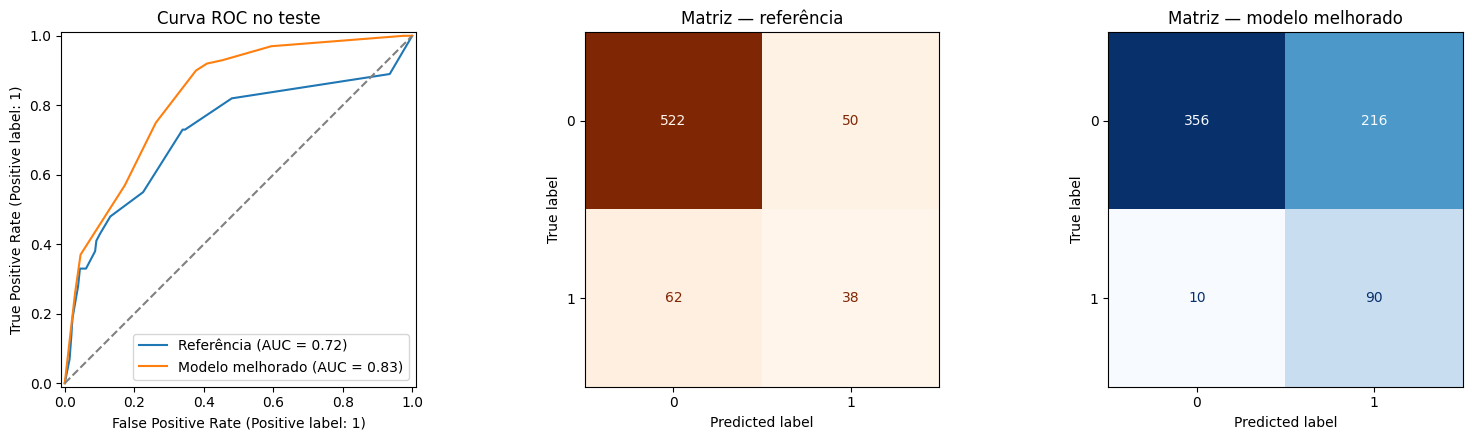

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

RocCurveDisplay.from_predictions(
    y_test, reference_score, name="Referência", ax=axes[0]
)
RocCurveDisplay.from_predictions(
    y_test, final_score, name="Modelo melhorado", ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Curva ROC no teste")

ConfusionMatrixDisplay.from_predictions(
    y_test, reference_pred, ax=axes[1], colorbar=False, cmap="Oranges"
)
axes[1].set_title("Matriz — referência")

ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred, ax=axes[2], colorbar=False, cmap="Blues"
)
axes[2].set_title("Matriz — modelo melhorado")

plt.tight_layout()
plt.show()

## 7. Importância das features e conclusão

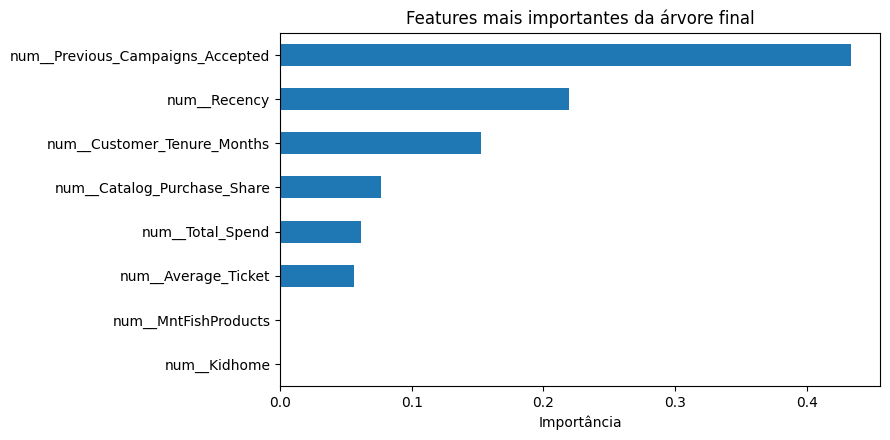

In [13]:
# Importância das features

feature_names = final_model.named_steps["prep"].get_feature_names_out()

importance = pd.Series(
    final_model.named_steps["tree"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_importance = importance.head(8).sort_values()

ax = top_importance.plot(
    kind="barh",
    figsize=(9, 4.5)
)

ax.set_title("Features mais importantes da árvore final")
ax.set_xlabel("Importância")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Conclusão

O modelo melhorado elevou o ROC AUC de 0,722 para 0,826, com ganho absoluto de 0,104 no teste preservado.

As principais contribuições vieram de:

1. Previous_Campaigns_Accepted, representando o histórico de aceitação de campanhas;
2. Recency, indicando o tempo desde a última compra;
3. Customer_Tenure_Months, representando o tempo de relacionamento com o cliente;
4. tuning realizado somente no treino com validação cruzada estratificada.

O modelo apresentou maior Recall e F1-score, embora com redução de Precision. O conjunto de teste permaneceu reservado para a avaliação final, evitando data leakage.